# Imports

In [ ]:
from google.colab import drive

drive.mount("/content/drive")
import sys, os
from pathlib import Path

sys.path.append("/content/drive/MyDrive/NFL/nfl2/")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from src.config import Config
from src.preprocess import (
    load_and_preprocess,
    preprocess
)
from src.model import (
    MLPRegressor,
    train_model,
    PFTransformer,
    train_all_folds,
)
from src.utils import (
    set_seed,
    set_folder,
)
import json
import joblib
import numpy as np

In [ ]:
# @title Random Seed
RANDOM_SEED = 888
set_seed(RANDOM_SEED)

# Data

In [ ]:
# @title Reset file paths

Config.BASE_DIR = Path("/content/drive/MyDrive/NFL/nfl2")
Config.DATA_DIR = Path("/content/drive/MyDrive/NFL/nfl_big_data_bowl_2026_prediction/")
Config.G_DATA_DIR = Path("/content/drive/MyDrive/NFL/nfl2/data/")
Config.G_DATA_VERSION = 25
Config.TRAIN_PATH = Config.DATA_DIR / "train"
Config.OUTPUT_DIR = Path("/content/drive/MyDrive/NFL/ckpt/")
Config.DEBUG = False
set_folder()  # set folder structure for experiment outputs

Config.TIME_TAG: 2025_12_03_04_50_20
Config.SAVE_DIR: /content/drive/MyDrive/NFL/ckpt/2025_12_03_04_50_20


In [ ]:
Config.TRAIN = True

In [ ]:
# @title Preprocess data

CWDIR = Path("/content/drive/MyDrive/NFL/nfl/")
train_data_path = Config.G_DATA_DIR / f"train_data_{Config.G_DATA_VERSION}.npz"
val_data_path = Config.G_DATA_DIR / f"val_data_{Config.G_DATA_VERSION}.npz"
scaler_path = Config.G_DATA_DIR / f"scaler_{Config.G_DATA_VERSION}.pkl"
fold_path = Config.G_DATA_DIR / f"gkf_split_{Config.G_DATA_VERSION}.pkl"

if not os.path.exists(
    train_data_path
):  # comment out if preprocessing needs to be completed again (updating new features)
    if Config.split_type == "gkf":
        _input_df, _output_df = preprocess()
        X, K, y, m, scaler, fold_indices = load_and_preprocess(_input_df, _output_df)
        import joblib

        joblib.dump(scaler, scaler_path)
        joblib.dump(fold_indices, fold_path)
        np.savez(train_data_path, X_train=X, K_train=K, y_train=y, m_train=m)
    else:  # tts, train_test_split
        X_train, K_train, y_train, m_train, X_val, K_val, y_val, m_val, scaler = (
            load_and_preprocess()
        )
        np.savez(
            train_data_path,
            X_train=X_train,
            K_train=K_train,
            y_train=y_train,
            m_train=m_train,
        )
        np.savez(val_data_path, X_val=X_val, K_val=K_val, y_val=y_val, m_val=m_val)

        import joblib

        joblib.dump(scaler, scaler_path)

In [ ]:
# @title Load Data

if Config.TRAIN:
    if Config.split_type == "tts":  # train_test_split
        Xt = np.load(train_data_path)
        Xv = np.load(val_data_path)
        import joblib

        scaler = joblib.load(scaler_path)

        X_train, K_train, y_train, m_train = (
            Xt["X_train"],
            Xt["K_train"],
            Xt["y_train"],
            Xt["m_train"],
        )
        X_val, K_val, y_val, m_val = Xv["X_val"], Xv["K_val"], Xv["y_val"], Xv["m_val"]

        from src.preprocess import get_dataloaders

        train_loader, val_loader = get_dataloaders(
            X_train,
            K_train,
            y_train,
            m_train,
            X_val,
            K_val,
            y_val,
            m_val,
        )

        input_dim = len(Config.feature_cols)

        print(f"#samples train: {len(train_loader.dataset)}")
        print(f"#samples val:   {len(val_loader.dataset)}")
        print(f"#features:      {input_dim}")
        print(f"#train batches: {len(train_loader)}")
        print(f"#eval batches:  {len(val_loader)}")

    else:  # gkfold
        train_loaded = np.load(train_data_path)
        X_train = train_loaded["X_train"]
        K_train = train_loaded["K_train"]
        y_train = train_loaded["y_train"]
        m_train = train_loaded["m_train"]
        import joblib

        fold_indices = joblib.load(fold_path)

# Training

In [ ]:
# @title Training Random Seeds
SEEDS = [888, 3407, 42, 0, 1]



Training on seed 888 ...
Random seed is set!
Training 5 folds ...
Training the 0-th fold ...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


--------------------------------------------------------------------------------------------
| Training has begun. Model of <class 'src_2.model.PFTransformer'> with 2190446 parameters |
--------------------------------------------------------------------------------------------
PFTransformer(
  (input_projection): Linear(in_features=111, out_features=128, bias=True)
  (drop): Dropout(p=0.1, inplace=False)
  (time_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)

Epoch 1/50 - train loss: 0.1640215498594568 - val loss: 0.19216885674853093 - val RMSE: 1.321411371231079 


Epoch 2/50 - train loss: 0.09296800577645815 - val loss: 0.09422823319952171 - val RMSE: 0.8601863384246826 


...

Epoch 46/50 - train loss: 0.041149269184419475 - val loss: 0.04353978333401156 - val RMSE: 0.5788233876228333 


Epoch 47/50 - train loss: 0.041443178792958266 - val loss: 0.04365148093816829 - val RMSE: 0.583550214767456 


Epoch 48/50 - train loss: 0.03989292544365753 - val loss: 0.043722588872653886 - val RMSE: 0.5828455686569214 


Epoch 49/50 - train loss: 0.03945000398057098 - val loss: 0.04354788730622859 - val RMSE: 0.5803428888320923 


Epoch 50/50 - train loss: 0.03996834026898145 - val loss: 0.04341243166253314 - val RMSE: 0.5756825804710388 
Best val RMSE: 0.5732 (weights saved to '/content/drive/MyDrive/NFL/ckpt/2025_12_03_04_50_20/seed_1/model.pt')
Finished training 4-th fold

[INFO] All folds finished, average RMSE over folds: 0.5596981525421143


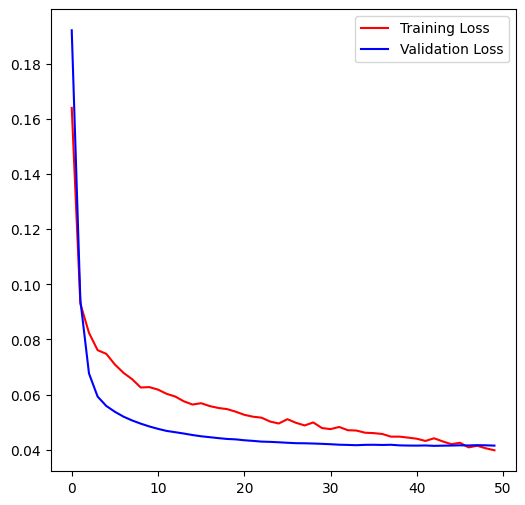

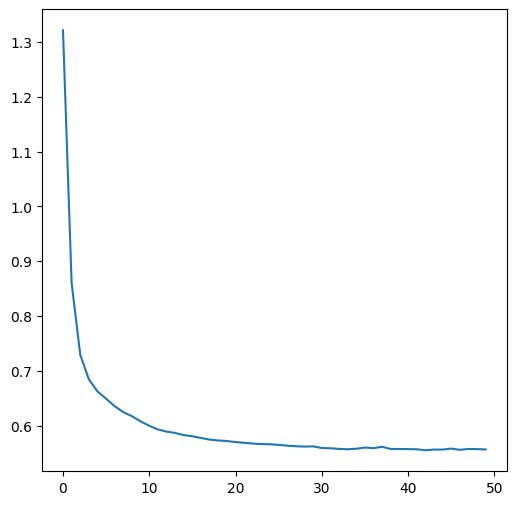

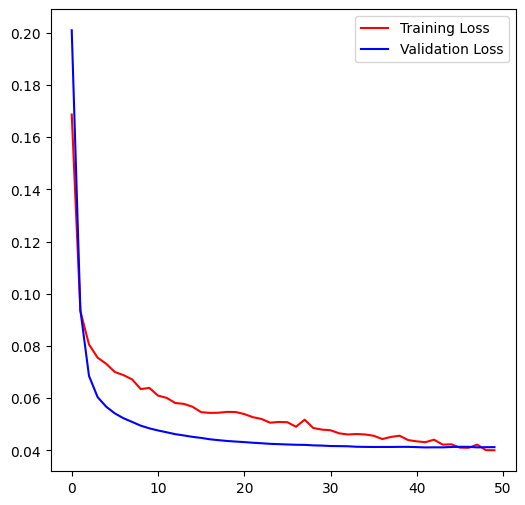

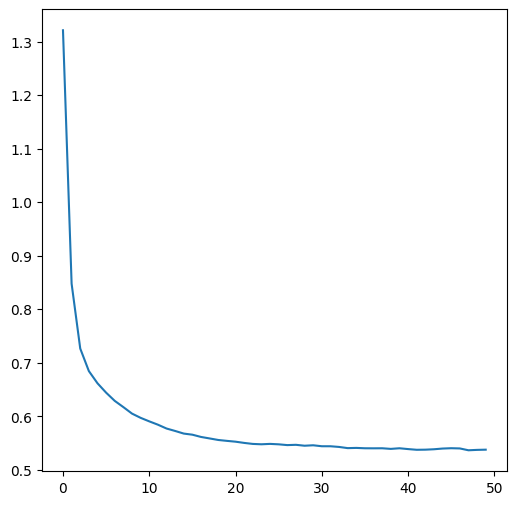

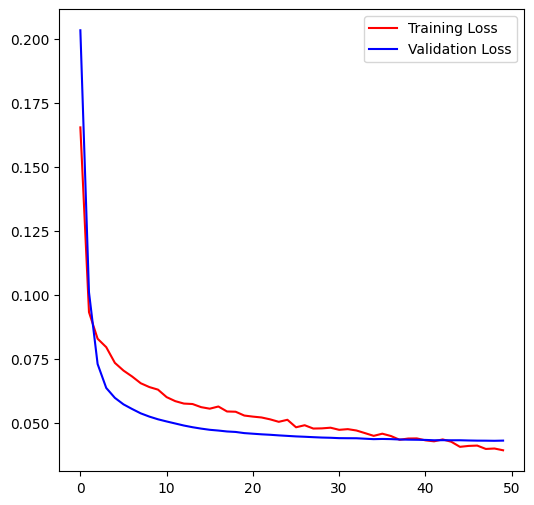

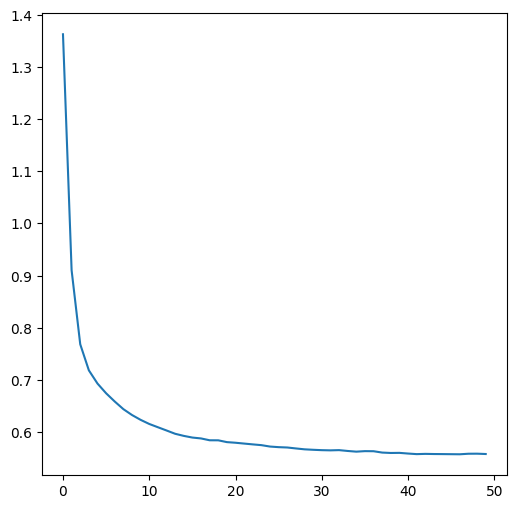

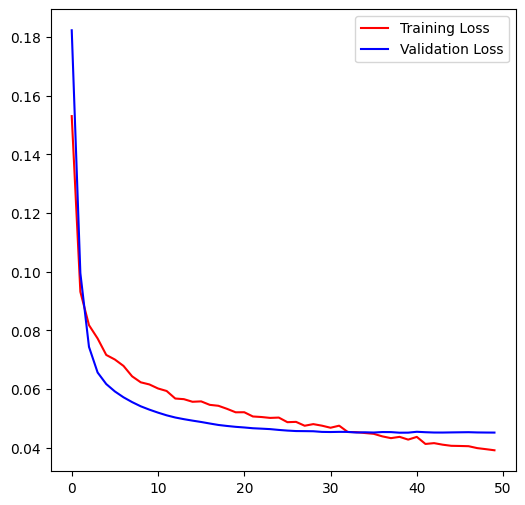

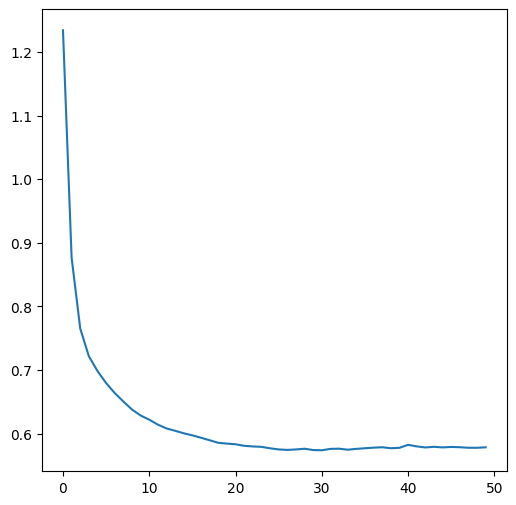

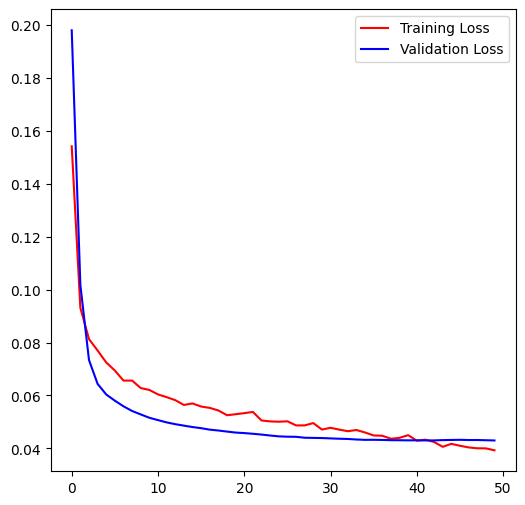

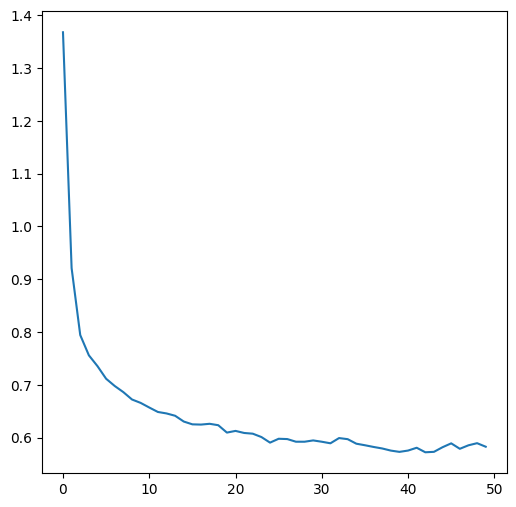

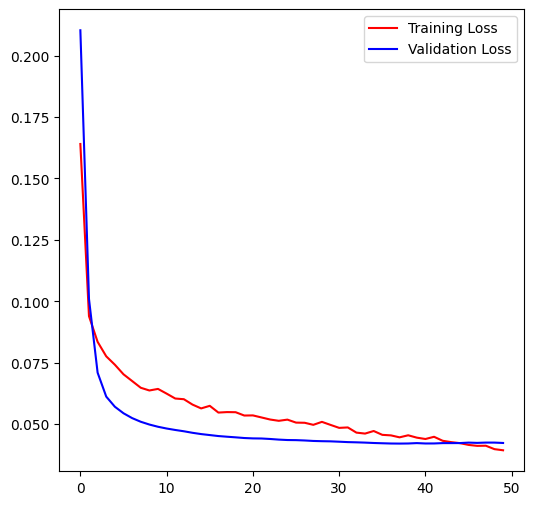

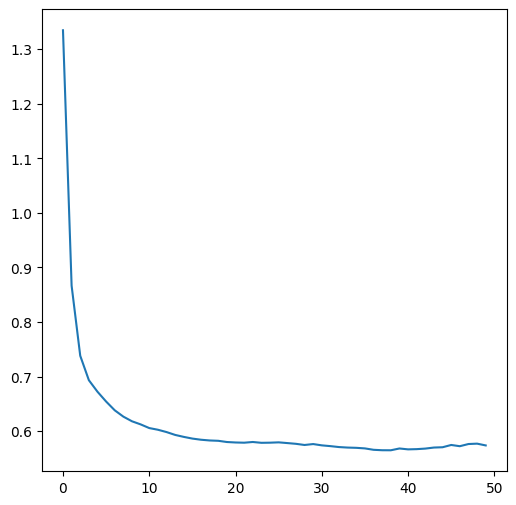

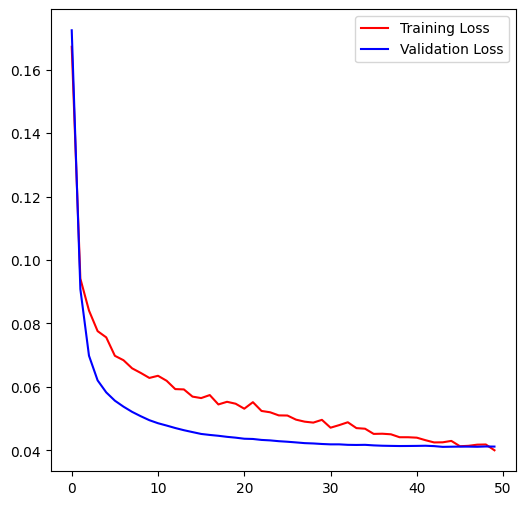

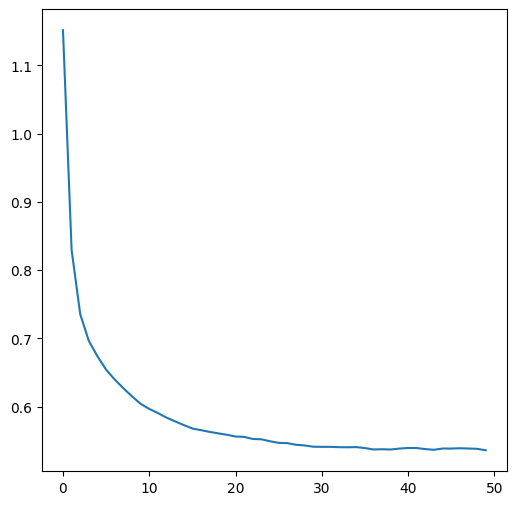

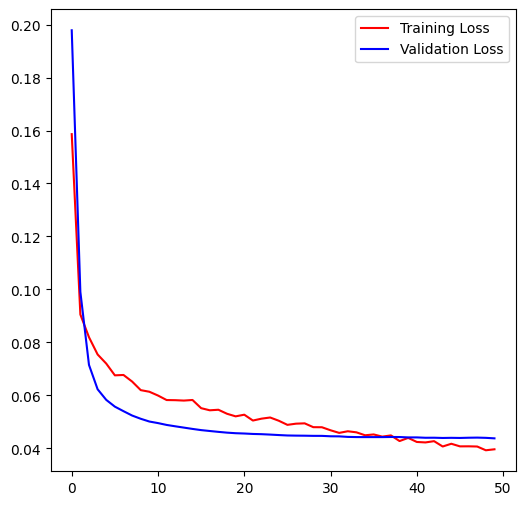

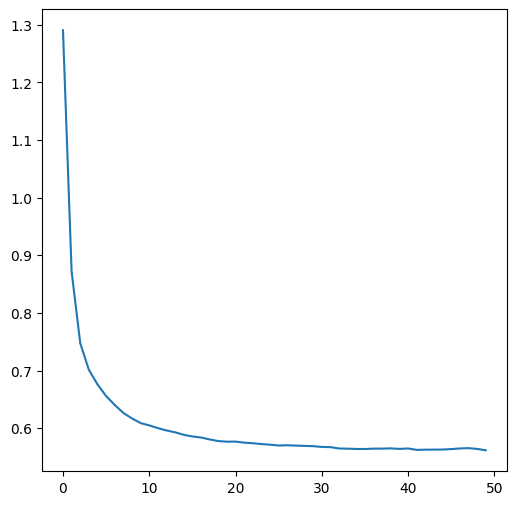

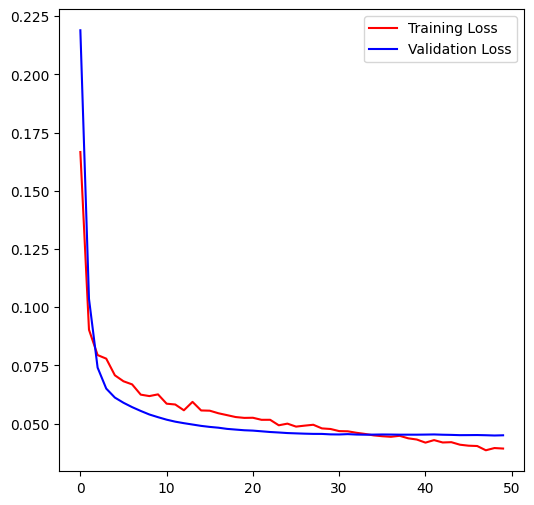

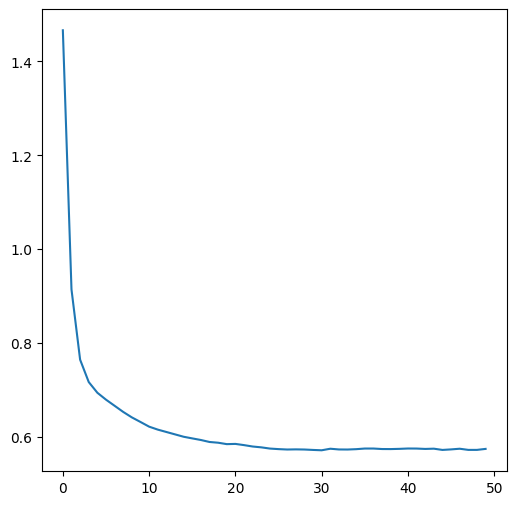

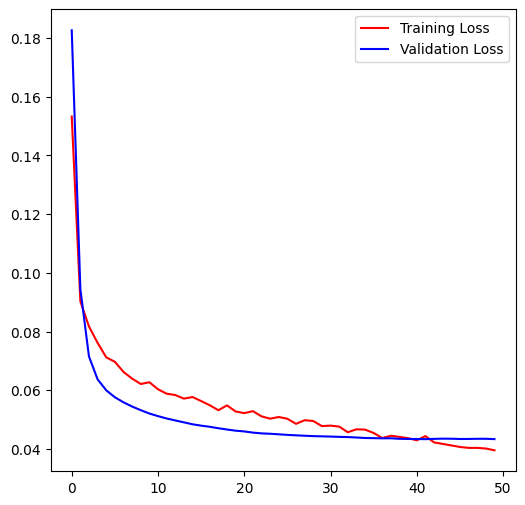

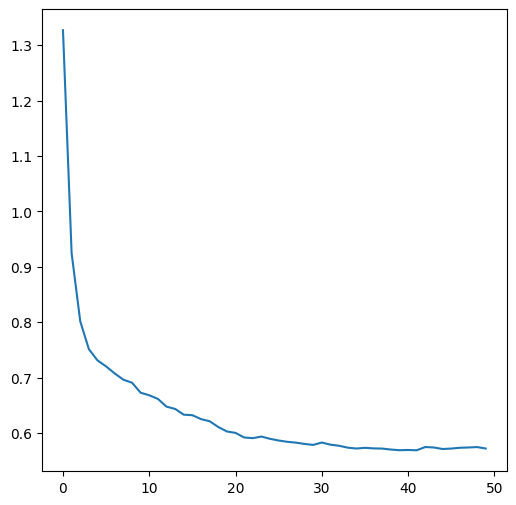

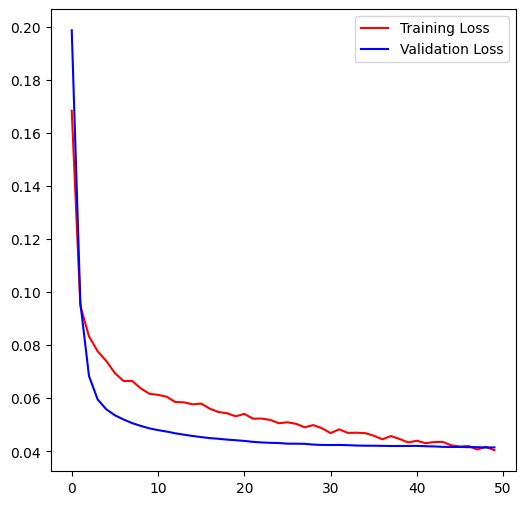

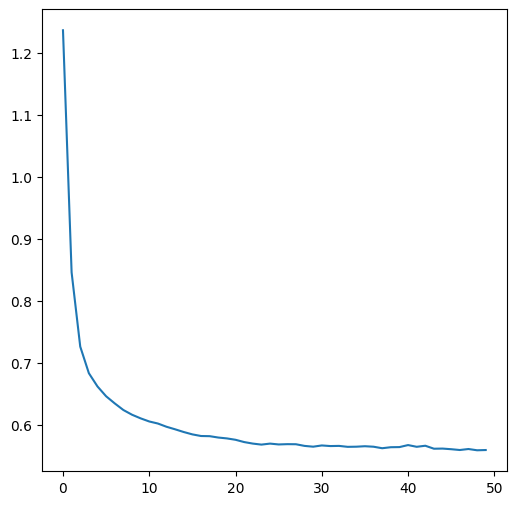

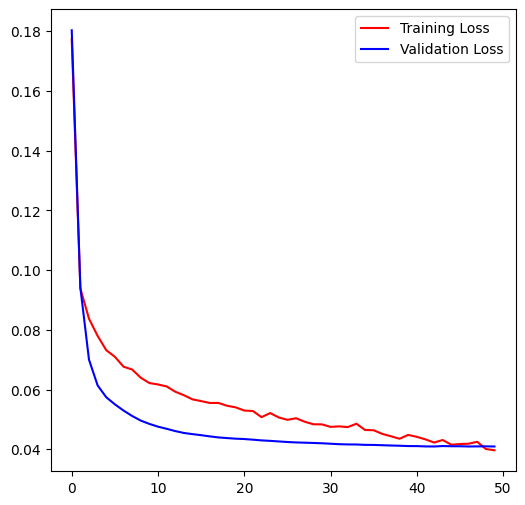

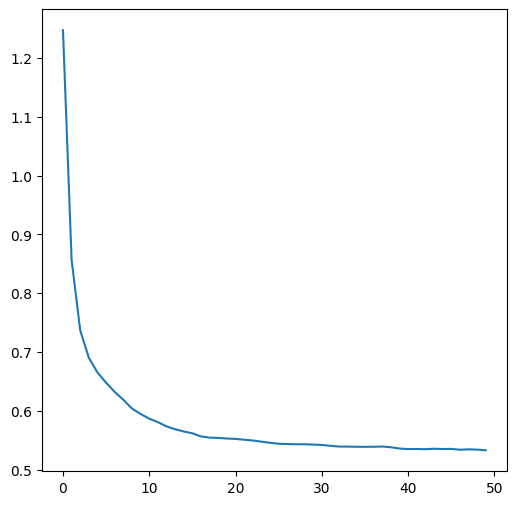

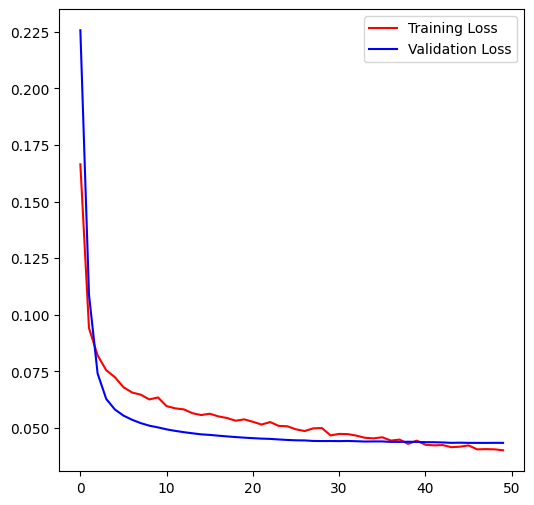

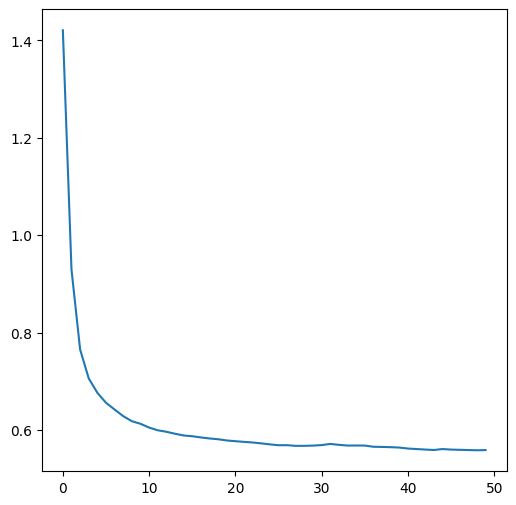

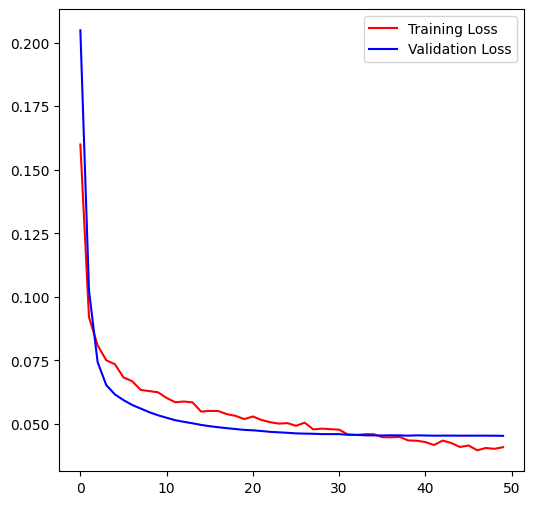

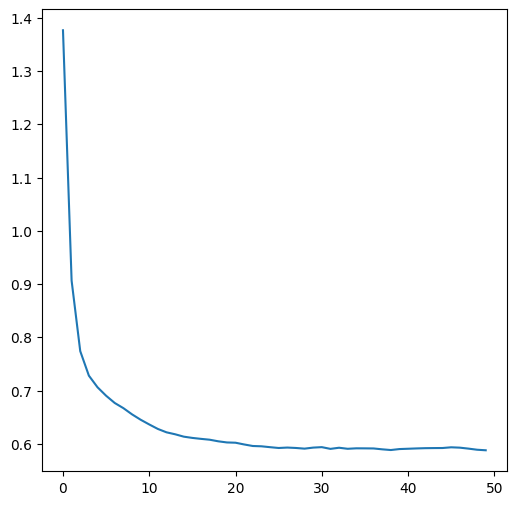

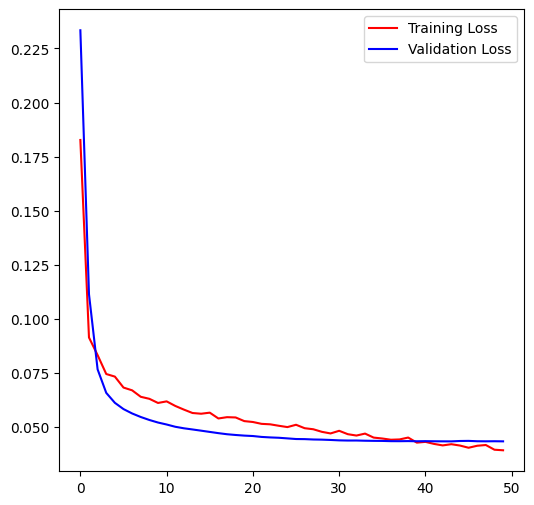

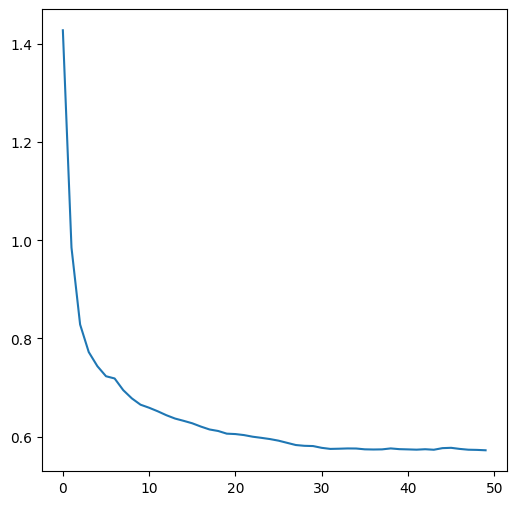

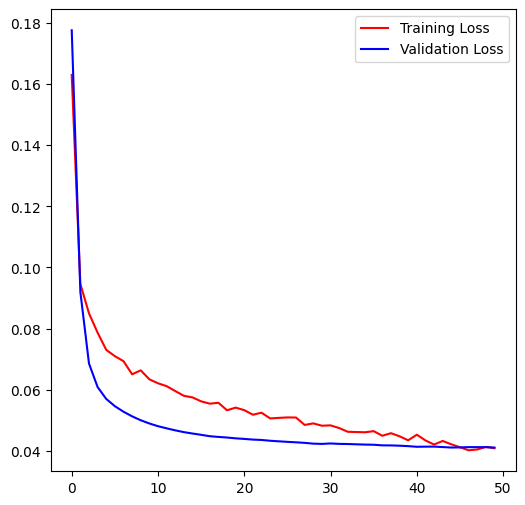

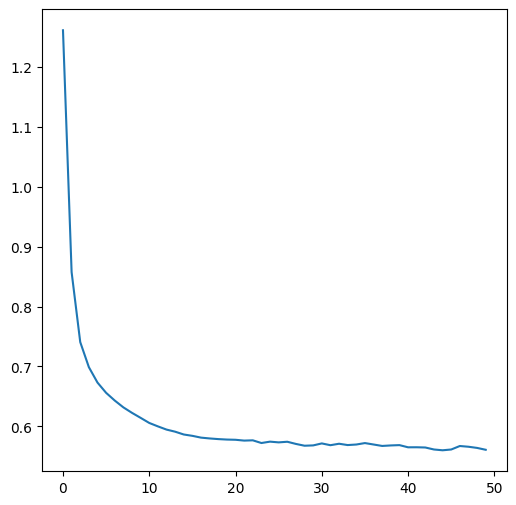

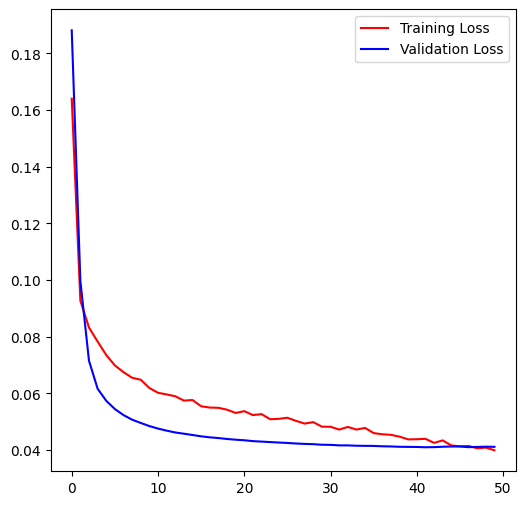

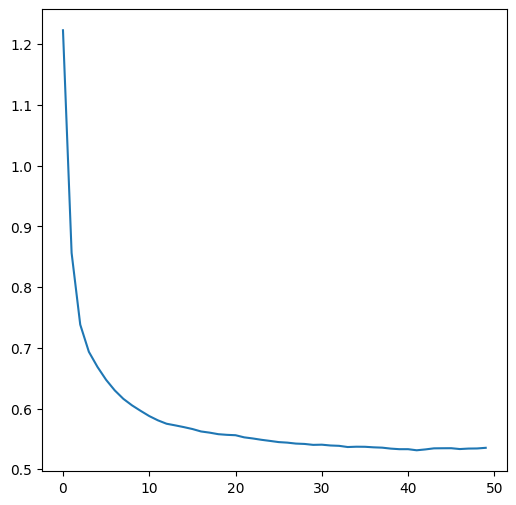

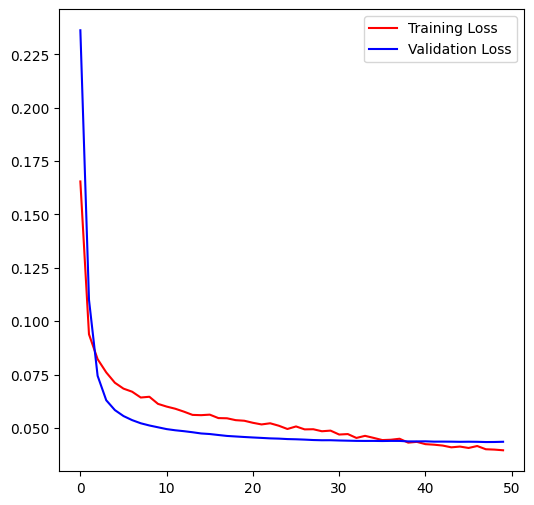

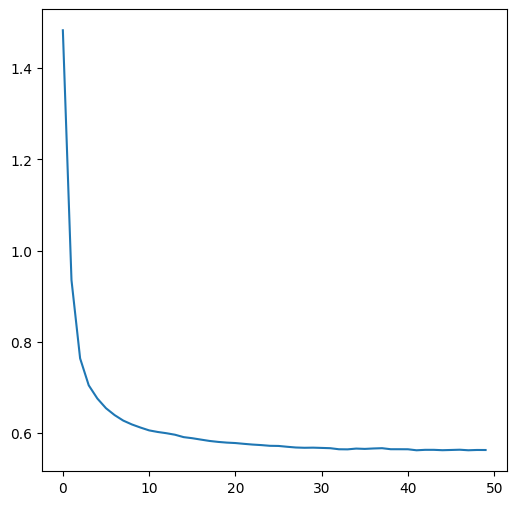

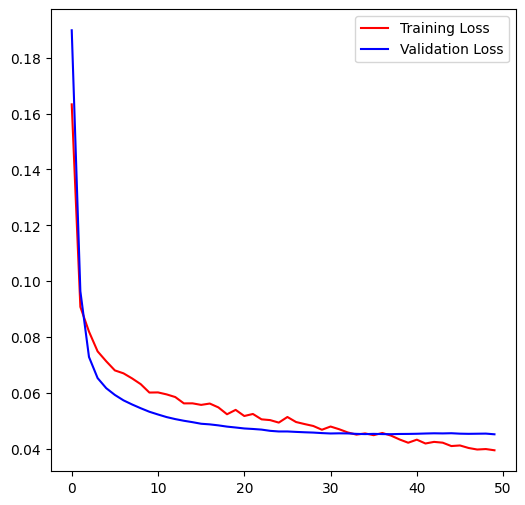

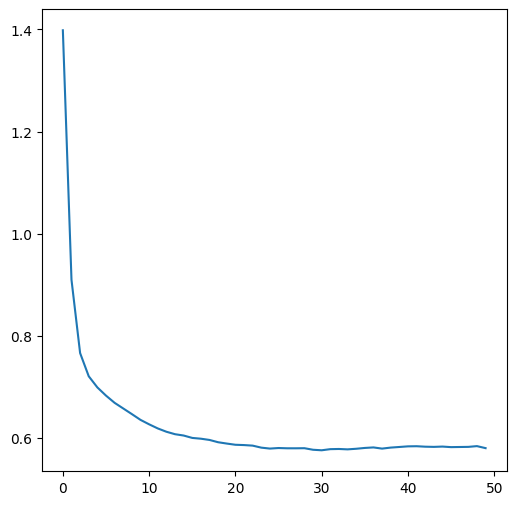

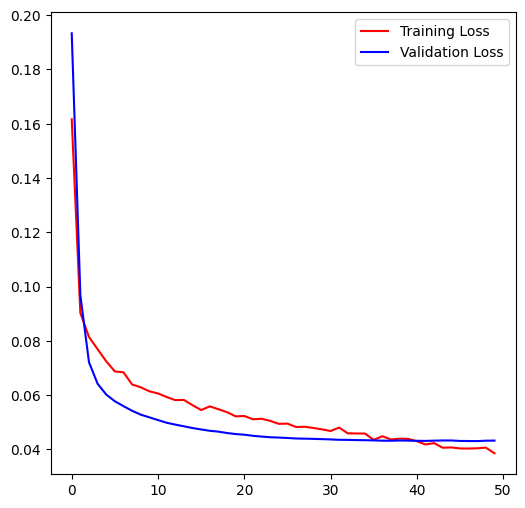

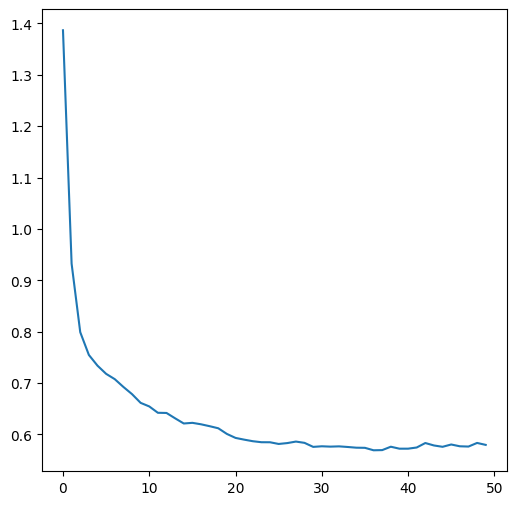

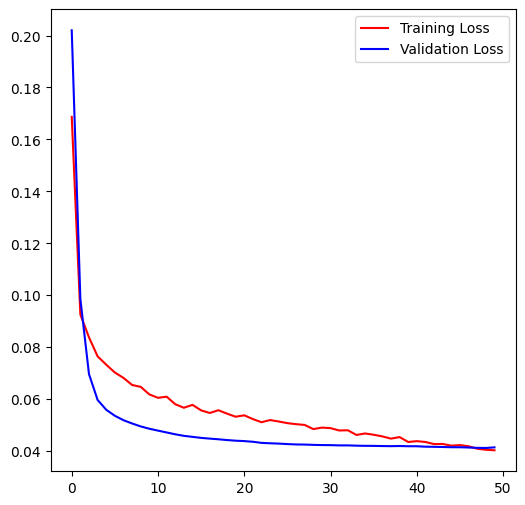

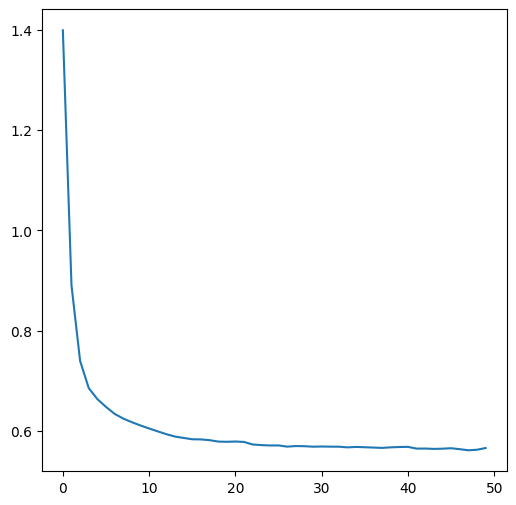

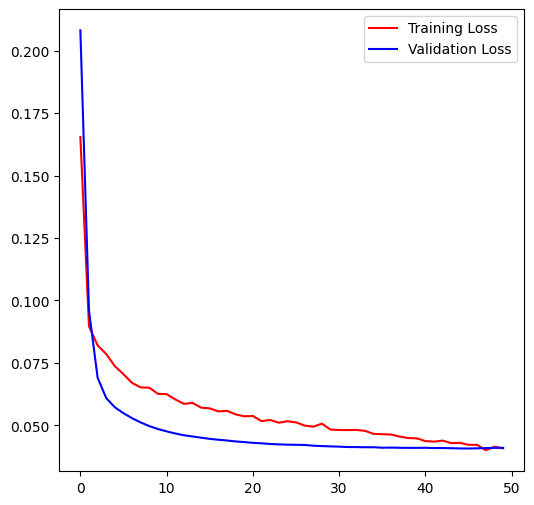

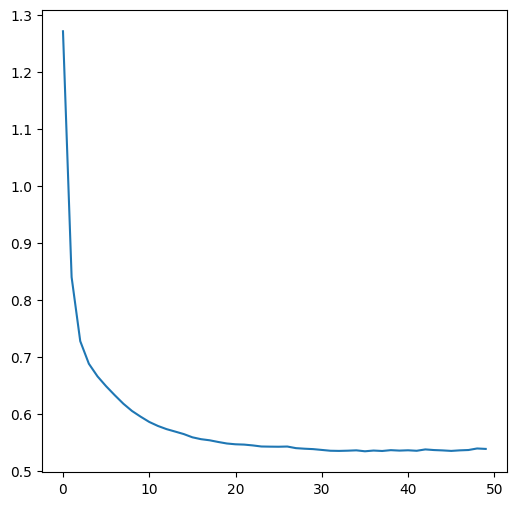

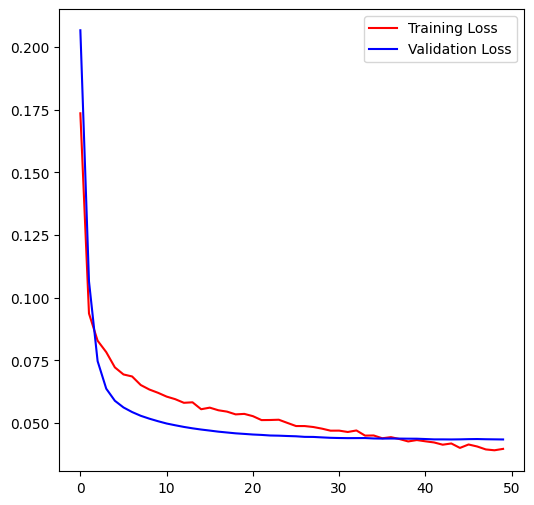

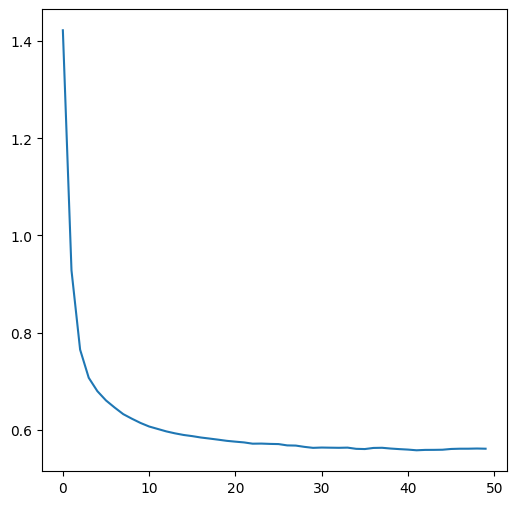

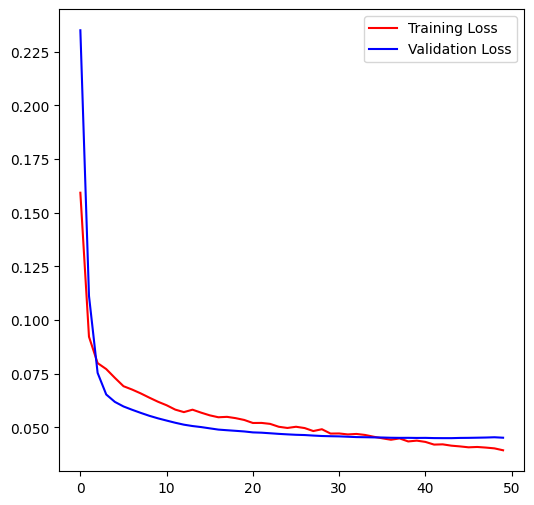

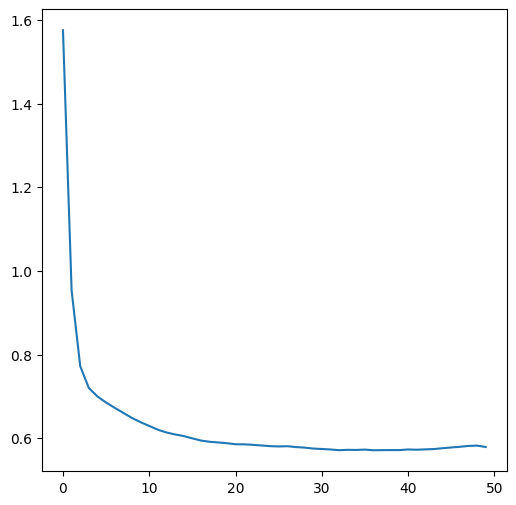

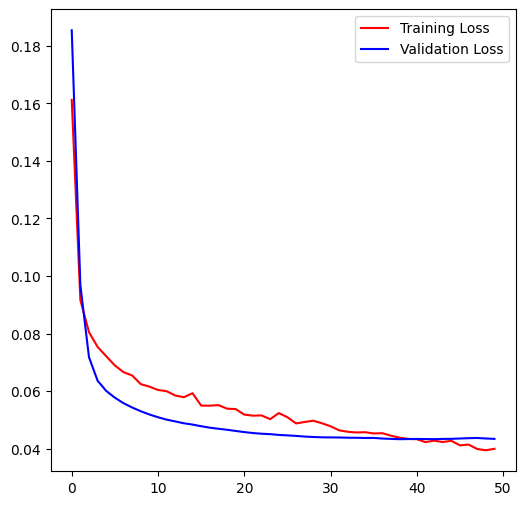

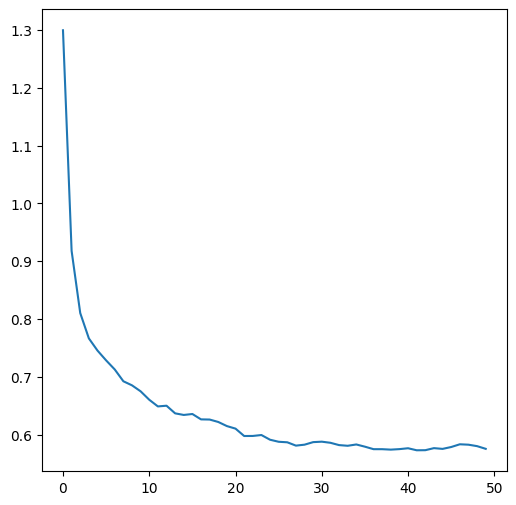

In [ ]:
if Config.TRAIN:
    if Config.split_type == "tts":
        for seed in SEEDS:
            print(f"\n\nTraining on seed {seed} ...")
            set_seed(seed)
            print(f"Random seed is set!")
            model = PFTransformer(
                input_dim=Config.input_dim,
                hidden_dim=Config.st_hidden_dim,
                output_dim=Config.output_dim,
                time_nheads=Config.time_nheads,
                player_nheads=Config.player_nheads,
                dim_feedforward=Config.dim_feedforward,
                num_time_encoder_layers=Config.num_time_encoder_layers,
                num_player_encoder_layers=Config.num_player_encoder_layers,
                dropout=Config.dropout,
            )
            print(f"Training Model: ")
            train_model(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                seed=seed,
                verbose=True,
                fold_id=0,  # assume it's only "1 fold"
            )

    else:
        for seed in SEEDS:
            print(f"\n\nTraining on seed {seed} ...")
            set_seed(seed)
            print(f"Random seed is set!")
            train_all_folds(
                X_train,
                K_train,
                y_train,
                m_train,
                fold_indices,
                seed=seed,
                verbose=True,
            )

# Submission

In [ ]:
Config.TEST_TAG = Config.TIME_TAG

In [ ]:
"""
The evaluation API requires that you set up a server which will respond to inference requests.
We have already defined the server; you just need write the predict function.
When we evaluate your submission on the hidden test set the client defined in `nfl_gateway` will run in a different container
with direct access to the hidden test set and hand off the data timestep by timestep.
Your code will always have access to the published copies of the copmetition files.
"""

import os

import pandas as pd
import polars as pl

sys.path.append("/content/drive/MyDrive/NFL/nfl_big_data_bowl_2026_prediction")
import kaggle_evaluation.nfl_inference_server
from src.predict import (
    pf_inference,
)

if Config.TRAIN:
    Config.TRAIN = False


def predict(
    test: pl.DataFrame, test_input: pl.DataFrame
) -> pl.DataFrame | pd.DataFrame:
    """Replace this function with your inference code.
    You can return either a Pandas or Polars dataframe, though Polars is recommended for performance.
    Each batch of predictions (except the very first) must be returned within 5 minutes of the batch features being provided.
    """
    # predictions = pl.DataFrame({'x': [0.0] * len(test), 'y': [0.0] * len(test)})
    if isinstance(test, pl.DataFrame):
        test = test.to_pandas()
    if isinstance(test_input, pl.DataFrame):
        test_input = test_input.to_pandas()

    predictions = pf_inference(test, test_input, time_tag=Config.TEST_TAG, seeds=SEEDS)

    assert isinstance(predictions, (pd.DataFrame, pl.DataFrame))
    assert len(predictions) == len(test)
    return predictions


# When your notebook is run on the hidden test set, inference_server.serve must be called within 10 minutes of the notebook starting
# or the gateway will throw an error. If you need more than 15 minutes to load your model you can do so during the very
# first `predict` call, which does not have the usual 5 minute response deadline.
inference_server = kaggle_evaluation.nfl_inference_server.NFLInferenceServer(predict)

if os.getenv("KAGGLE_IS_COMPETITION_RERUN"):
    inference_server.serve()
else:
    inference_server.run_local_gateway((Config.DATA_DIR,))

100%|██████████| 1/1 [00:00<00:00, 144.82it/s]


['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'player_height_inches', 'bmi', 'is_offense', 'is_defense', 'is_receiver', 'is_coverage', 'is_passer', 'player_role_type', 'orientation_diff', 'velocity_x', 'velocity_y', 'acceleration_x', 'acceleration_y', 'accel_magnitude', 'momentum_x', 'momentum_y', 'momentum_mag', 'speed_squared', 'kinetic_energy', 'inertia_momentum', 'velocity_x_delta', 'velocity_y_delta', 'speed_delta', 'jerk_x', 'jerk_y', 'jerk_mag', 'velocity_x_ema', 'velocity_y_ema', 'speed_ema', 'ball_distance', 'ball_distance_rank', 'ball_dx', 'ball_dy', 'ball_angle', 'ball_diff_dir', 'ball_diff_o', 'ball_unit_dx', 'ball_unit_dy', 'ball_proj_mag', 'closing_speed_ball', 'velocity_toward_ball', 'velocity_alignment_ball

Collating input ...: 100%|██████████| 1/1 [00:00<00:00, 2880.70it/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
100%|██████████| 1/1 [00:00<00:00, 197.71it/s]


['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'player_height_inches', 'bmi', 'is_offense', 'is_defense', 'is_receiver', 'is_coverage', 'is_passer', 'player_role_type', 'orientation_diff', 'velocity_x', 'velocity_y', 'acceleration_x', 'acceleration_y', 'accel_magnitude', 'momentum_x', 'momentum_y', 'momentum_mag', 'speed_squared', 'kinetic_energy', 'inertia_momentum', 'velocity_x_delta', 'velocity_y_delta', 'speed_delta', 'jerk_x', 'jerk_y', 'jerk_mag', 'velocity_x_ema', 'velocity_y_ema', 'speed_ema', 'ball_distance', 'ball_distance_rank', 'ball_dx', 'ball_dy', 'ball_angle', 'ball_diff_dir', 'ball_diff_o', 'ball_unit_dx', 'ball_unit_dy', 'ball_proj_mag', 'closing_speed_ball', 'velocity_toward_ball', 'velocity_alignment_ball

100%|██████████| 1/1 [00:00<00:00, 173.60it/s]


...

100%|██████████| 1/1 [00:00<00:00, 171.64it/s]


['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'player_height_inches', 'bmi', 'is_offense', 'is_defense', 'is_receiver', 'is_coverage', 'is_passer', 'player_role_type', 'orientation_diff', 'velocity_x', 'velocity_y', 'acceleration_x', 'acceleration_y', 'accel_magnitude', 'momentum_x', 'momentum_y', 'momentum_mag', 'speed_squared', 'kinetic_energy', 'inertia_momentum', 'velocity_x_delta', 'velocity_y_delta', 'speed_delta', 'jerk_x', 'jerk_y', 'jerk_mag', 'velocity_x_ema', 'velocity_y_ema', 'speed_ema', 'ball_distance', 'ball_distance_rank', 'ball_dx', 'ball_dy', 'ball_angle', 'ball_diff_dir', 'ball_diff_o', 'ball_unit_dx', 'ball_unit_dy', 'ball_proj_mag', 'closing_speed_ball', 'velocity_toward_ball', 'velocity_alignment_ball

100%|██████████| 1/1 [00:00<00:00, 126.87it/s]


['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'player_height_inches', 'bmi', 'is_offense', 'is_defense', 'is_receiver', 'is_coverage', 'is_passer', 'player_role_type', 'orientation_diff', 'velocity_x', 'velocity_y', 'acceleration_x', 'acceleration_y', 'accel_magnitude', 'momentum_x', 'momentum_y', 'momentum_mag', 'speed_squared', 'kinetic_energy', 'inertia_momentum', 'velocity_x_delta', 'velocity_y_delta', 'speed_delta', 'jerk_x', 'jerk_y', 'jerk_mag', 'velocity_x_ema', 'velocity_y_ema', 'speed_ema', 'ball_distance', 'ball_distance_rank', 'ball_dx', 'ball_dy', 'ball_angle', 'ball_diff_dir', 'ball_diff_o', 'ball_unit_dx', 'ball_unit_dy', 'ball_proj_mag', 'closing_speed_ball', 'velocity_toward_ball', 'velocity_alignment_ball

Collating input ...: 100%|██████████| 1/1 [00:00<00:00, 5817.34it/s]


# Test

In [ ]:
test = pd.read_csv(Config.DATA_DIR / "test.csv")
test_input = pd.read_csv(Config.DATA_DIR / "test_input.csv")
predictions = predict(test, test_input)

100%|██████████| 143/143 [00:00<00:00, 228.26it/s]


['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'player_height_inches', 'bmi', 'is_offense', 'is_defense', 'is_receiver', 'is_coverage', 'is_passer', 'player_role_type', 'orientation_diff', 'velocity_x', 'velocity_y', 'acceleration_x', 'acceleration_y', 'accel_magnitude', 'momentum_x', 'momentum_y', 'momentum_mag', 'speed_squared', 'kinetic_energy', 'inertia_momentum', 'velocity_x_delta', 'velocity_y_delta', 'speed_delta', 'jerk_x', 'jerk_y', 'jerk_mag', 'velocity_x_ema', 'velocity_y_ema', 'speed_ema', 'ball_distance', 'ball_distance_rank', 'ball_dx', 'ball_dy', 'ball_angle', 'ball_diff_dir', 'ball_diff_o', 'ball_unit_dx', 'ball_unit_dy', 'ball_proj_mag', 'closing_speed_ball', 'velocity_toward_ball', 'velocity_alignment_ball

Collating input ...: 100%|██████████| 143/143 [00:00<00:00, 19433.80it/s]


In [ ]:
predictions.head()

,x,y
0,88.341706,34.296413
1,88.650107,34.310227
2,88.975746,34.377370
3,89.324005,34.477542
4,89.672926,34.642303


In [ ]:
test = pd.read_csv(Config.TRAIN_PATH / "output_2023_w01.csv")
test_input = pd.read_csv(Config.TRAIN_PATH / "input_2023_w01.csv")

bad_game_id = 2023091100
bad_play_id = 3167

test = test[~((test["game_id"] == bad_game_id) & (test["play_id"] == bad_play_id))]
test_input = test_input[
    ~((test_input["game_id"] == bad_game_id) & (test_input["play_id"] == bad_play_id))
]

predictions = predict(test.drop(columns=["x", "y"]), test_input)

100%|██████████| 818/818 [00:03<00:00, 231.43it/s]


['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'player_height_inches', 'bmi', 'is_offense', 'is_defense', 'is_receiver', 'is_coverage', 'is_passer', 'player_role_type', 'orientation_diff', 'velocity_x', 'velocity_y', 'acceleration_x', 'acceleration_y', 'accel_magnitude', 'momentum_x', 'momentum_y', 'momentum_mag', 'speed_squared', 'kinetic_energy', 'inertia_momentum', 'velocity_x_delta', 'velocity_y_delta', 'speed_delta', 'jerk_x', 'jerk_y', 'jerk_mag', 'velocity_x_ema', 'velocity_y_ema', 'speed_ema', 'ball_distance', 'ball_distance_rank', 'ball_dx', 'ball_dy', 'ball_angle', 'ball_diff_dir', 'ball_diff_o', 'ball_unit_dx', 'ball_unit_dy', 'ball_proj_mag', 'closing_speed_ball', 'velocity_toward_ball', 'velocity_alignment_ball

Collating input ...: 100%|██████████| 818/818 [00:00<00:00, 20167.18it/s]


In [ ]:
predictions.head()

,x,y
0,56.221680,17.289342
1,56.637903,16.892198
2,57.060075,16.474172
3,57.499711,16.029374
4,57.936285,15.568208


In [ ]:
import torch
from src_2.utils import evaluate_rmse


def RMSE(y_pred, y_true):
    sq_err = (y_pred - y_true) ** 2
    return ((0.5 * sq_err.mean()) ** 0.5).item()


y_pred = torch.tensor(predictions.values)
y_true = torch.tensor(test[["x", "y"]].values)
rmse = RMSE(y_pred, y_true)  #
rmse

0.28362704638786307

In [ ]:
test[["x", "y"]].head()

,x,y
0,56.22,17.28
1,56.63,16.88
2,57.06,16.46
3,57.48,16.02
4,57.91,15.56
